# Laboratorio 2 - Questao 1a

Este notebook implementa o filtro de media movel pedido no Laboratorio 2 usando laco de repeticao e compara o resultado com `scipy.signal.lfilter`, exatamente como foi apresentado no Laboratorio 1.

Equacao de diferencas usada:

`y[n] = 0.25 x[n] + 0.25 x[n-1] + 0.25 x[n-2] + 0.25 x[n-3]`, com amostras anteriores a `n = 0` iguais a 0.


Entrada (data):
[  7.  14.  11.  43.  38.  61.  75.  38.  12.  18.  18.  17.  19.  32.
  42.  57.  44. 114.  35.  11.  13.  10.]

Saida calculada com lacos:
[ 1.75  5.25  8.   18.75 26.5  38.25 54.25 53.   46.5  35.75 21.5  16.25
 18.   21.5  27.5  37.5  43.75 64.25 62.5  51.   43.25 17.25]

Saida com scipy.signal.lfilter:
[ 1.75  5.25  8.   18.75 26.5  38.25 54.25 53.   46.5  35.75 21.5  16.25
 18.   21.5  27.5  37.5  43.75 64.25 62.5  51.   43.25 17.25]

As duas saidas sao iguais? True
Erro maximo entre os metodos: 0.000000


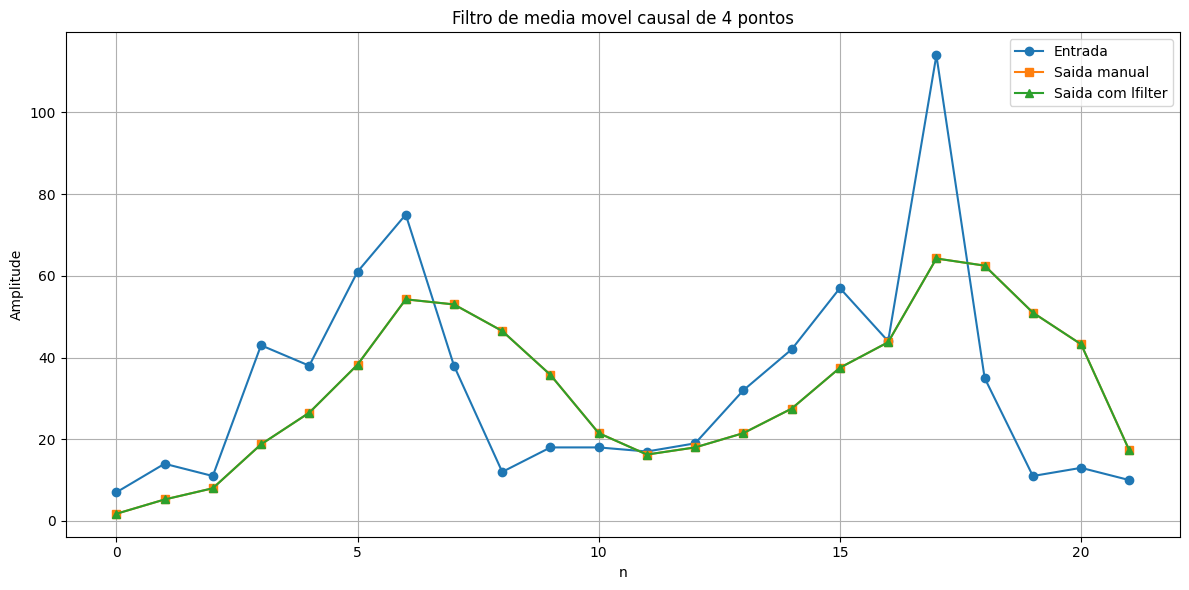

In [1]:
from __future__ import annotations

from collections.abc import Sequence
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

MOVING_AVERAGE_POINTS = 4


def plot_series(
    series: Sequence[dict[str, Any]],
    title: str,
    xlabel: str,
    ylabel: str,
    figsize: tuple[float, float] = (12, 6),
    grid: bool = True,
    legend: bool = True,
    tight_layout: bool = True,
) -> None:
    """Plota uma ou mais series no mesmo grafico."""

    plt.figure(figsize=figsize)

    for item in series:
        x_values = item.get("x")
        y_values = item["y"]
        plot_kwargs = item.get("plot_kwargs", {})

        if x_values is None:
            plt.plot(y_values, **plot_kwargs)
        else:
            plt.plot(x_values, y_values, **plot_kwargs)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(grid)

    if legend:
        plt.legend()

    if tight_layout:
        plt.tight_layout()

    plt.show()


def moving_average_manual(x: np.ndarray) -> np.ndarray:
    """Implementa a media movel causal de 4 pontos usando lacos."""

    y = np.zeros(len(x), dtype=float)

    for n in range(len(x)):
        accumulator = 0.0

        for k in range(MOVING_AVERAGE_POINTS):
            index = n - k
            accumulator += x[index] if index >= 0 else 0.0

        y[n] = accumulator / MOVING_AVERAGE_POINTS

    return y


def moving_average_lfilter(x: np.ndarray):
    """Aplica a mesma equacao com a funcao pronta usada no Lab 1."""

    b = np.ones(MOVING_AVERAGE_POINTS, dtype=float) / MOVING_AVERAGE_POINTS
    a = np.array([1.0], dtype=float)
    return signal.lfilter(b, a, x)


def main() -> None:
    data = np.array(
        [7, 14, 11, 43, 38, 61, 75, 38, 12, 18, 18, 17, 19, 32, 42, 57, 44, 114, 35, 11, 13, 10],
        dtype=float,
    )

    manual_output = moving_average_manual(data)
    l_filter_out = moving_average_lfilter(data)
    maxError = np.max(np.abs(manual_output - l_filter_out))
    indexes = np.arange(len(data))

    print("Entrada (data):")
    print(data)

    print("\nSaida calculada com lacos:")
    print(np.round(manual_output, 2))

    print("\nSaida com scipy.signal.lfilter:")
    print(np.round(l_filter_out, 2))

    print(f"\nAs duas saidas sao iguais? {np.allclose(manual_output, l_filter_out)}")
    print(f"Erro maximo entre os metodos: {maxError:.6f}")

    plot_series(
        series=[
            {
                "x": indexes,
                "y": data,
                "plot_kwargs": {"marker": "o", "label": "Entrada"},
            },
            {
                "x": indexes,
                "y": manual_output,
                "plot_kwargs": {"marker": "s", "label": "Saida manual"},
            },
            {
                "x": indexes,
                "y": l_filter_out,
                "plot_kwargs": {"marker": "^", "label": "Saida com lfilter"},
            },
        ],
        title="Filtro de media movel causal de 4 pontos",
        xlabel="n",
        ylabel="Amplitude",
    )


main()


## Explicacao do resultado

Como a saida em cada amostra depende da media entre o valor atual e os tres valores anteriores, o filtro suaviza variacoes bruscas do sinal de entrada. Por isso, picos como os maiores valores do vetor ficam menos acentuados na saida.

A implementacao manual e a funcao `signal.lfilter` produzem o mesmo vetor porque ambas aplicam a mesma equacao de diferencas com a mesma condicao inicial nula. Isso fecha exatamente o que o item `1a)` pede: implementar com lacos, plotar entrada e saida, comparar com a funcao pronta e explicar o comportamento observado.
